Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [1]:
import matplotlib.pyplot as plt
import requests
import numpy as np

In [2]:
#do not re-execute this cell



# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)


In [3]:

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])
print(names)

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


/tmp/ipykernel_12784/439950167.py:2: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [19]:
T90 = data[6, :].astype(float)
T90[T90 == -999] = np.nan
T90 = T90[~ np.isnan(T90)]
T90_err = data[7,:].astype(float)
T90_reshape = T90.reshape(-1, 1)



In [18]:
T90

array([2.04800e+01, 1.44000e-01, 1.37600e+01, ..., 3.13600e+00,
       2.08576e+02, 5.18400e+00], shape=(7982,))

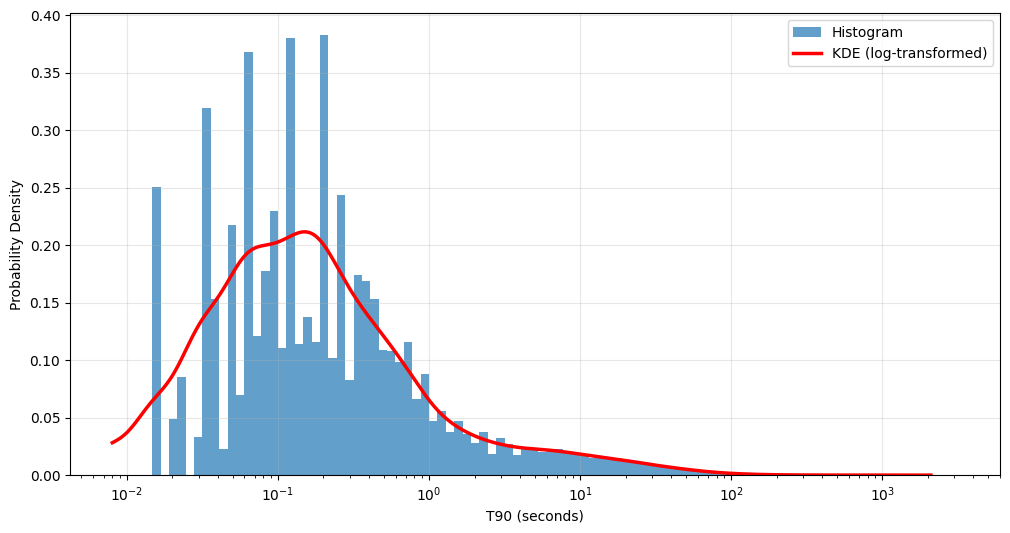

In [22]:
from scipy.stats import gaussian_kde
import numpy as np

# Work with positive values only
T90_positive = T90[T90 > 0]
T90_log = np.log10(T90_positive)

# KDE on log scale
kde_log = gaussian_kde(T90_log, bw_method='scott')
x_log = np.linspace(T90_log.min(), T90_log.max(), 1000)
pdf_log = kde_log(x_log)

# Transform back to original scale (with Jacobian)
x_original = 10**x_log
pdf_original = pdf_log / (x_original * np.log(10))

# Plot
plt.figure(figsize=(12, 6))
plt.hist(T90_positive, bins=np.logspace(-2, 3.5, 100), alpha=0.7, density=True, label='Histogram')
plt.plot(x_original, pdf_original, 'r-', linewidth=2.5, label='KDE (log-transformed)')
plt.xscale('log')
plt.xlabel('T90 (seconds)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


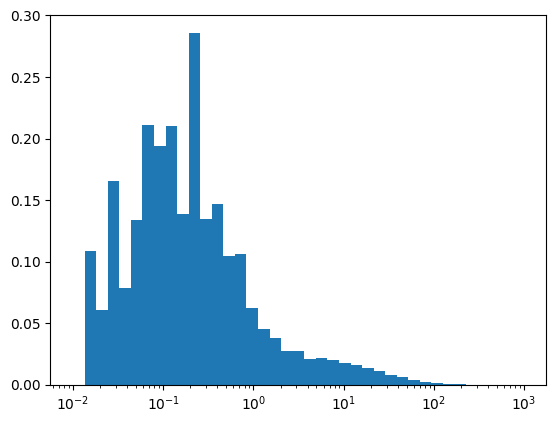

In [5]:
# plt.hist(data[6, :], bins = np.logspace(0, 100, 100))
plt.hist(T90,bins= np.logspace(-2,3,40), density = True)
plt.xscale('log')

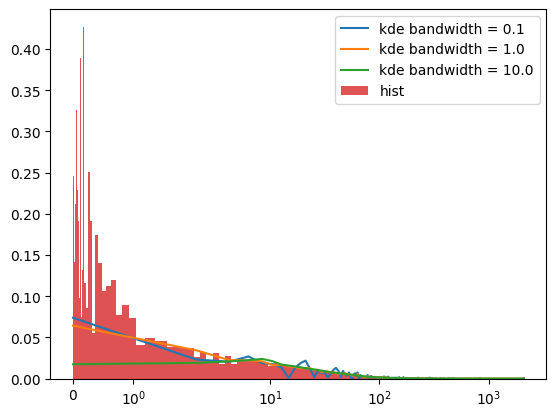

In [13]:
from sklearn.neighbors import KernelDensity

x = np.linspace(np.min(T90), np.max(T90), 1000)
bandwidths = np.logspace(-1, 1, 3)
for band in bandwidths:
    kde = KernelDensity(bandwidth = band, kernel = 'tophat')
    kde.fit(T90_reshape)
    pdf = np.exp(kde.score_samples(x.reshape(-1, 1)))
    plt.plot(x, pdf, label = f"kde bandwidth = {band}")

plt.hist(T90,bins= np.logspace(-2,3,90), alpha  = 0.8, density = True, label = 'hist' )
plt.xscale('symlog')
plt.legend()

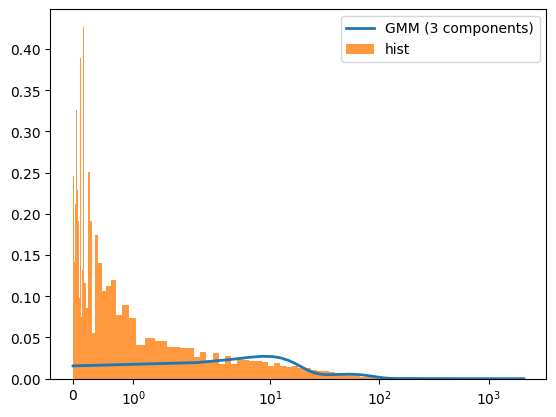

In [14]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3).fit(T90_reshape)
pdf_gmm = np.exp(gmm.score_samples(x.reshape(-1, 1)))

plt.plot(x, pdf_gmm, label='GMM (3 components)', linewidth=2)
plt.hist(T90, bins=np.logspace(-2, 3, 90), alpha=0.8, density=True, label='hist')
plt.xscale('symlog')
plt.legend()
plt.show()


In [9]:
from sklearn.model_selection import GridSearchCV
bandwidths = np.linspace(0.1, 10, 10)
print (bandwidths)
grid  = GridSearchCV(KernelDensity(), {'bandwidth': bandwidths}, cv = 5) #5 k-fold cross validation
grid.fit(T90_reshape)
print(grid.best_params_['bandwidth'])

[ 0.1  1.2  2.3  3.4  4.5  5.6  6.7  7.8  8.9 10. ]
10.0


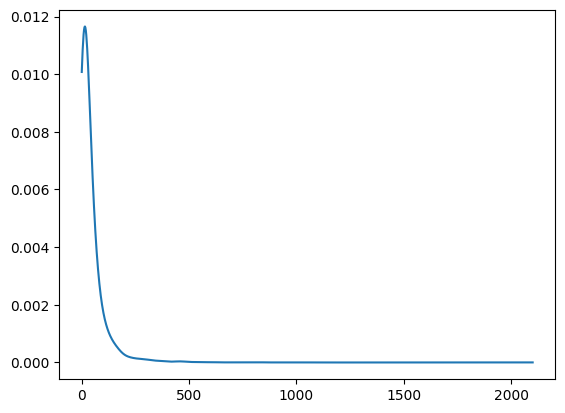

In [10]:
kde = KernelDensity(bandwidth = 22)
kde.fit(T90_reshape)
pdf = np.exp(kde.score_samples(x.reshape(-1, 1)))
plt.plot(x, pdf, label = f"kde bandwidth = 22")
